In [268]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [269]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.autograd import grad

In [270]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [272]:
iris = load_iris()

Создаем датасет и смотри первые 10 строк

In [273]:
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Убедимя в том, что у нас нет пропущенных значений

In [274]:
iris_df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


Заменим текстовые значения на числовые

In [275]:
iris_df.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [276]:
species_mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
iris_df['species'] = iris_df['species'].map(species_mapping)

Рассмотрим матрицу корреляций

<Axes: >

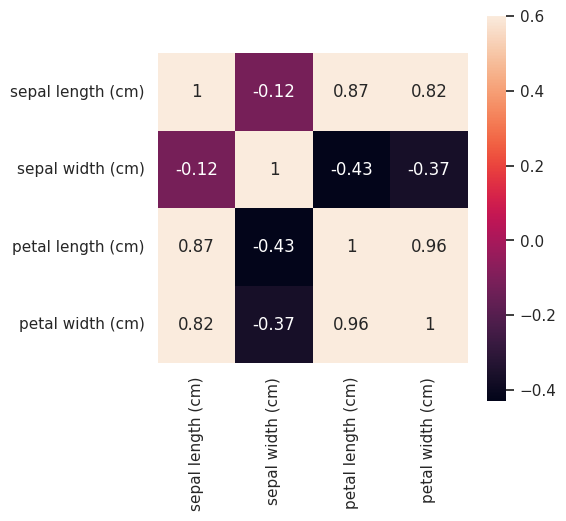

In [277]:
numeric_columns = iris_df.select_dtypes(include=['number'] )
corr_matrix = numeric_columns.corr()
plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, vmax=0.6, square=True, annot=True)

средние значения каждого из признаков в сравнении с тремя видами

/tmp/ipython-input-4071255907.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = iris_df.groupby('species').mean().round(2)


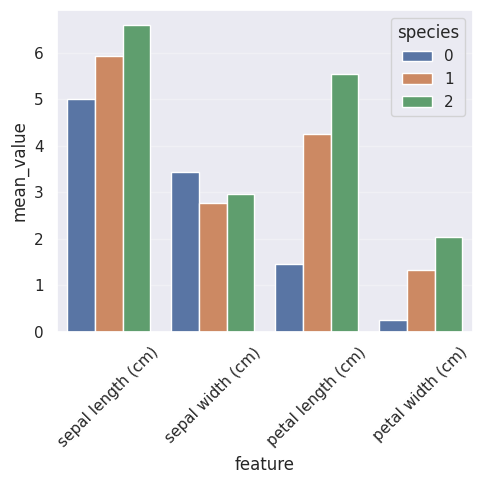

In [278]:
summary_table = iris_df.groupby('species').mean().round(2)

plt.figure(figsize=(5, 5))

summary_for_plot = summary_table.reset_index().melt(
    id_vars='species',
    var_name='feature',
    value_name='mean_value'
)
sns.barplot(data=summary_for_plot, x='feature', y='mean_value', hue='species')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Нейросеть для которой на вход подается 4 параметра, на выход - 3 класса

In [279]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 3),
        )

    def forward(self, x):
        return self.layers(x)

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=3, bias=True)
  )
)


Разделяем на тестовую и тренировочную выборку, нормализуем

In [280]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Преобразуем датасет для работы с PyTorch

In [281]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.features = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.int64)

    def __getitem__(self, index):
        x = self.features[index]
        y = self.labels[index]
        return x, y

    def __len__(self):
        return len(self.features)

train_dataset = MyDataset(X_train, y_train)
test_dataset = MyDataset(X_test, y_test)

разбиваем датасет на батчи, перемешиваем данные

In [282]:
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=2, shuffle=True, num_workers=0)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=2, shuffle=False, num_workers=0)

обучение

In [283]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    #цикл по батчам
    for (idx, (x, y)) in enumerate(train_dataloader):
        model_result = model(x)
        loss = F.cross_entropy(model_result, y)  #функция потерь

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [284]:
model.eval()
for (idx, (x, y)) in enumerate(test_dataloader):
    with torch.no_grad():
        outputs = torch.argmax(torch.softmax(model(x), dim=1), dim=1)

проверим точность

In [285]:
def accuracy(model, dataloader):
    model.eval()
    correct = sum((torch.argmax(model(x), dim=1) == y).sum().item()
                 for x, y in dataloader)
    total = sum(y.size(0) for x, y in dataloader)
    return 100 * correct / total

tr = accuracy(model, train_dataloader)
tst = accuracy(model, test_dataloader)

print(f"Точность на тренировочных: {tr:.1f}%")
print(f"на тестовых:  {tst:.1f}%")

Точность на тренировочных: 98.3%
на тестовых:  96.7%
